In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
fadata_id = "benchmark_pancrease_500"

[10/27/2025 07:43:23] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

read trajectory result

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: '20251020_161304__scvelo-cfe_docker__JV5pLHC89R'                                                                                            
                      DEBUG    parse 'MilestoneWrapper' object for 20251020_161304__scvelo-cfe_docker__JV5pLHC89R                                                                                   

<Axes: title={'center': 'veloae-cfe_docker(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

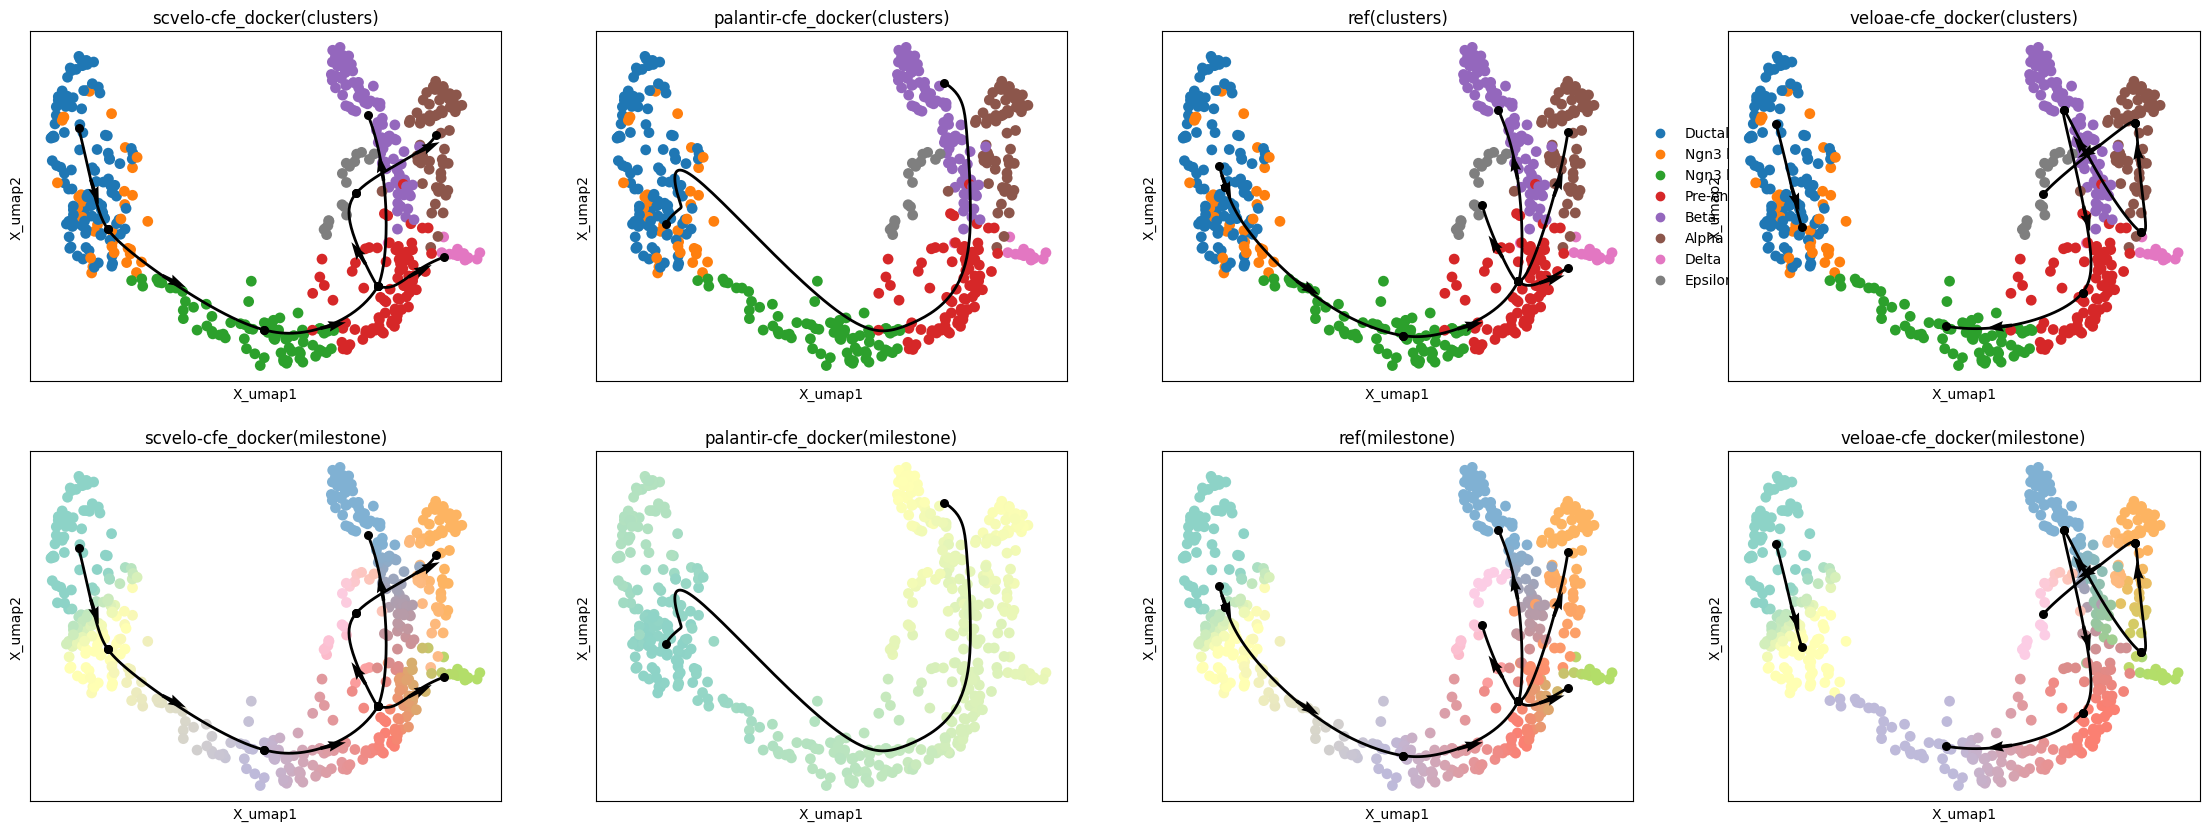

In [2]:
fadata = cfe.data.read_h5ad("output.h5ad")
fadata.id = fadata_id
fadata.load_trajectory_dict(model_name_list=["20251023_163939__veloae-cfe_docker__M3CJuMqPQC"])


model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cfe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

[10/27/2025 07:43:42] DEBUG    'ref' is not a valid random_time_string, don't need parse                                                                                                                
                      DEBUG    match pased:'veloae-cfe_docker' to raw:'20251023_163939__veloae-cfe_docker__M3CJuMqPQC'                                                                                  
                      DEBUG    start_milestone is None, try to use start cell to identify start milestone automatically                                                                                 
                      DEBUG    extract start_cell('cell_000') from prior information                                                                                                                    
                      DEBUG    'ref' is not a valid random_time_string, don't need parse                                                                                                            

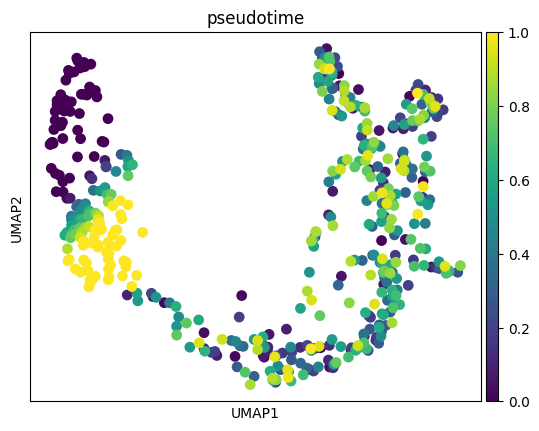

In [ ]:
import scanpy as sc

model_name = "veloae-cfe_docker"
# 对于非连通图会报错, 暂时把他全设置为0
# 设置为0,当起点非联通时全局为0, 计算伪时间相关性会报错, 需要设置其他为随机值
fadata.obs["pseudotime"] = fadata.get_trajectory_pseudotime(model_name=model_name)
sc.pl.umap(fadata, color="pseudotime", cmap="viridis")